# Social Media Sentiment Analysis using AI/NLP

**Project Type:** Data Analytics with AI — IBM SkillsBuild Academic Internship (AICTE x BharatCares)

**Objective:** Analyze social media posts across multiple platforms, classify them into **Positive**, **Negative**, and **Neutral** sentiment using Natural Language Processing (NLP) and Machine Learning, and generate actionable business insights.

**Dataset:** `social_media_sentiment_data.csv` — 1,800 social media posts across Twitter, Instagram, Facebook and YouTube, covering 12 product/service topics, with engagement metrics (likes, retweets) and sentiment labels.

---


In [1]:
# 1. Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
from collections import Counter

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

pd.set_option("display.max_colwidth", 100)
print("Libraries loaded successfully.")


Matplotlib is building the font cache; this may take a moment.


Libraries loaded successfully.


## 1. Load Dataset

In [2]:
df = pd.read_csv("social_media_sentiment_data.csv")
print("Shape:", df.shape)
df.head()


Shape: (2020, 8)


,post_id,date,platform,topic,text,likes,retweets,sentiment
0,POST00530,2025-12-22 11:00,Facebook,fitness tracker,"The fitness tracker update ruined everything, please fix this asap.",6,5,Negative
1,POST00495,2025-02-19 14:00,YouTube,laptop brand,"The laptop brand update ruined everything, please fix this asap. 👎",0,1,Negative
2,POST00395,2025-12-21 07:00,Facebook,online banking app,"Really disappointed with online banking app, expected way better. 😡",32,0,Negative
3,POST01865,2025-03-02 11:00,Facebook,e-commerce sale,"The e-commerce sale is okay I guess, nothing special but works.",5,1,Neutral
4,POST01491,2025-01-10 08:00,Instagram,cloud gaming service,"Saw an ad for cloud gaming service today, might check it out later. 🤔",57,0,Neutral


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 2020 entries, 0 to 2019
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   post_id    2020 non-null   str  
 1   date       2020 non-null   str  
 2   platform   2020 non-null   str  
 3   topic      2020 non-null   str  
 4   text       2020 non-null   str  
 5   likes      2020 non-null   int64
 6   retweets   2020 non-null   int64
 7   sentiment  2020 non-null   str  
dtypes: int64(2), str(6)
memory usage: 126.4 KB


In [4]:
df.isnull().sum()


post_id      0
date         0
platform     0
topic        0
text         0
likes        0
retweets     0
sentiment    0
dtype: int64

## 2. Exploratory Data Analysis (EDA)

sentiment
Positive    717
Neutral     688
Negative    615
Name: count, dtype: int64


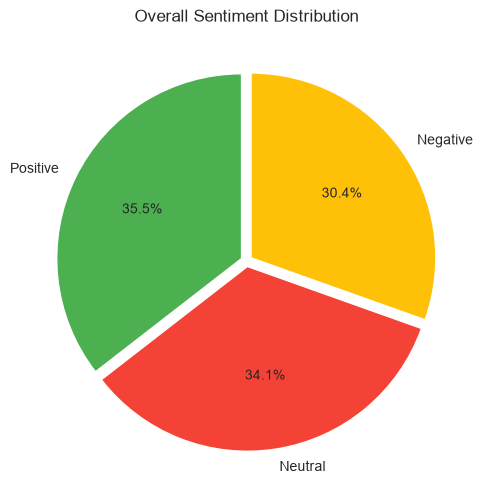

In [5]:
# Sentiment distribution
sentiment_counts = df["sentiment"].value_counts()
print(sentiment_counts)

plt.figure(figsize=(6,6))
colors = ["#4CAF50", "#F44336", "#FFC107"]
plt.pie(sentiment_counts, labels=sentiment_counts.index, autopct="%1.1f%%",
        colors=colors, startangle=90, explode=[0.03]*3)
plt.title("Overall Sentiment Distribution")
plt.show()


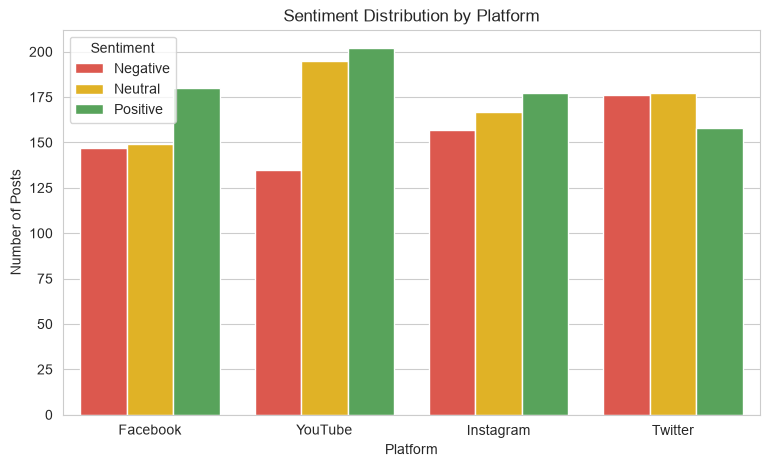

In [6]:
# Platform-wise sentiment distribution
plt.figure(figsize=(9,5))
sns.countplot(data=df, x="platform", hue="sentiment",
              palette={"Positive": "#4CAF50", "Negative": "#F44336", "Neutral": "#FFC107"})
plt.title("Sentiment Distribution by Platform")
plt.xlabel("Platform")
plt.ylabel("Number of Posts")
plt.legend(title="Sentiment")
plt.show()


C:\Users\nikky\AppData\Local\Temp\ipykernel_28408\1494354410.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="sentiment", y="likes",


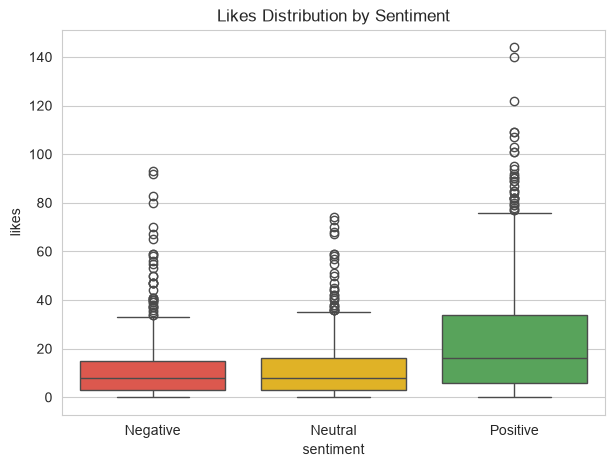

In [7]:
# Engagement (likes) by sentiment
plt.figure(figsize=(7,5))
sns.boxplot(data=df, x="sentiment", y="likes",
            palette={"Positive": "#4CAF50", "Negative": "#F44336", "Neutral": "#FFC107"})
plt.title("Likes Distribution by Sentiment")
plt.show()


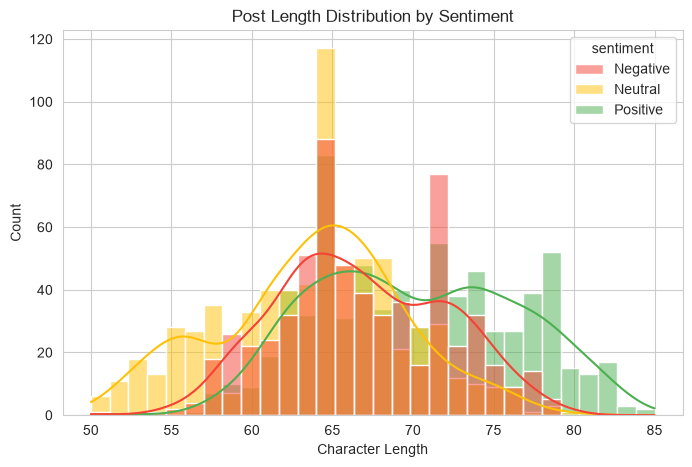

In [8]:
# Post length distribution
df["text_length"] = df["text"].apply(len)

plt.figure(figsize=(8,5))
sns.histplot(data=df, x="text_length", hue="sentiment", bins=30, kde=True,
             palette={"Positive": "#4CAF50", "Negative": "#F44336", "Neutral": "#FFC107"})
plt.title("Post Length Distribution by Sentiment")
plt.xlabel("Character Length")
plt.show()


## 3. Text Preprocessing

In [9]:
STOPWORDS = set('''a an the is are was were be been being i you he she it we they
me him her us them my your his its our their this that these those and or but if
so to of in on at for with as by from about into over after before up down out
just not no nor than too very can will would should could did do does have has had
today just so its it's im i'm get got going go'''.split())

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)           # remove URLs
    text = re.sub(r"@\w+", "", text)                      # remove mentions
    text = re.sub(r"#", "", text)                          # keep hashtag word, drop symbol
    text = text.translate(str.maketrans("", "", string.punctuation))
    text = re.sub(r"[^\x00-\x7F]+", " ", text)            # remove emojis/non-ascii
    tokens = [w for w in text.split() if w not in STOPWORDS and len(w) > 2]
    return " ".join(tokens)

df["clean_text"] = df["text"].apply(clean_text)
df[["text", "clean_text"]].head(10)


,text,clean_text
0,"The fitness tracker update ruined everything, please fix this asap.",fitness tracker update ruined everything please fix asap
1,"The laptop brand update ruined everything, please fix this asap. 👎",laptop brand update ruined everything please fix asap
2,"Really disappointed with online banking app, expected way better. 😡",really disappointed online banking app expected way better
3,"The e-commerce sale is okay I guess, nothing special but works.",ecommerce sale okay guess nothing special works
4,"Saw an ad for cloud gaming service today, might check it out later. 🤔",saw cloud gaming service might check later
5,"The online banking app update ruined everything, please fix this asap. 😞",online banking app update ruined everything please fix asap
6,Why is e-commerce sale so slow today? Getting really annoyed. 😞,why ecommerce sale slow getting really annoyed
7,"The electric car broke down after just one week, very poor quality. 😡",electric car broke one week poor quality
8,"Absolutely loving the new smartphone, works flawlessly! #happy",absolutely loving new smartphone works flawlessly happy
9,Why is cloud gaming service so slow today? Getting really annoyed. 😞,why cloud gaming service slow getting really annoyed


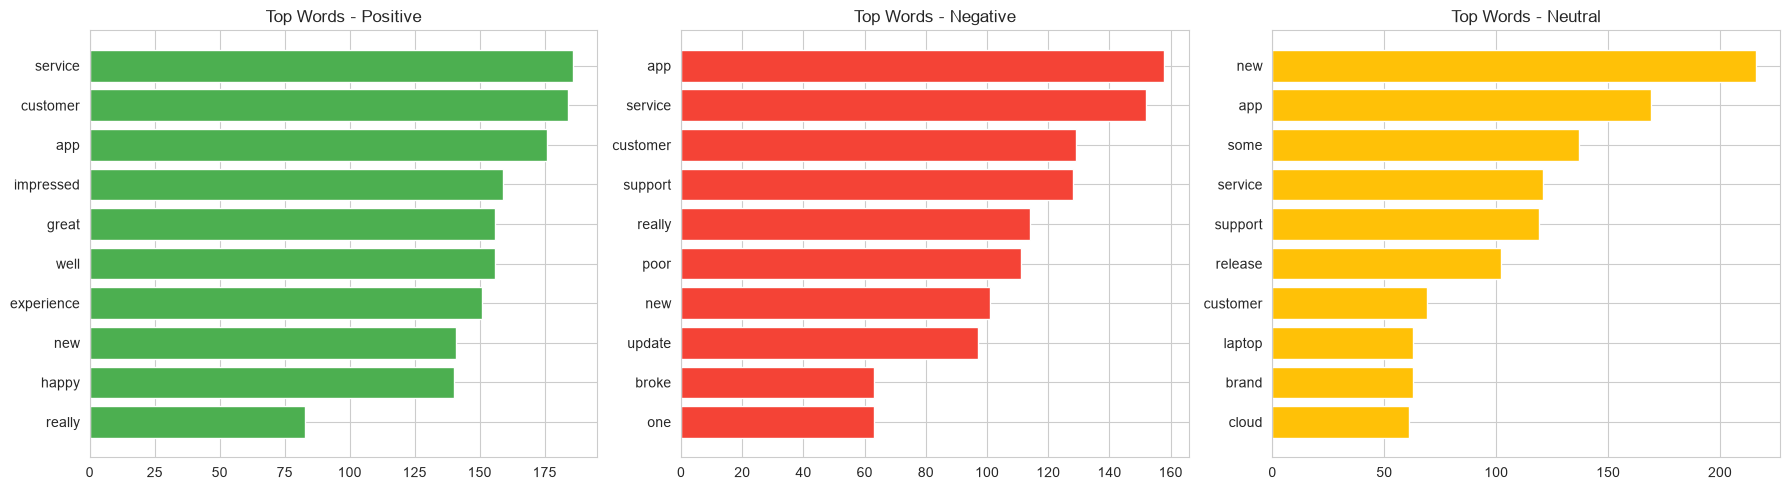

In [10]:
# Most frequent words per sentiment class
fig, axes = plt.subplots(1, 3, figsize=(18,5))
for ax, sentiment, color in zip(axes, ["Positive", "Negative", "Neutral"],
                                 ["#4CAF50", "#F44336", "#FFC107"]):
    words = " ".join(df[df["sentiment"] == sentiment]["clean_text"]).split()
    common = Counter(words).most_common(10)
    labels, values = zip(*common)
    ax.barh(labels[::-1], values[::-1], color=color)
    ax.set_title(f"Top Words - {sentiment}")
plt.tight_layout()
plt.show()


## 4. Feature Engineering — TF-IDF Vectorization

In [11]:
tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1,2))
X = tfidf.fit_transform(df["clean_text"])
y = df["sentiment"]

print("Feature matrix shape:", X.shape)


Feature matrix shape: (2020, 867)


## 5. Train-Test Split & Model Building

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Train size:", X_train.shape[0], "| Test size:", X_test.shape[0])


Train size: 1616 | Test size: 404


In [13]:
# Model 1: Logistic Regression
log_reg = LogisticRegression(max_iter=1000, C=2.0)
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)

acc_lr = accuracy_score(y_test, y_pred_lr)
print(f"Logistic Regression Accuracy: {acc_lr:.4f}")
print(classification_report(y_test, y_pred_lr))


Logistic Regression Accuracy: 0.9678
              precision    recall  f1-score   support

    Negative       0.98      0.96      0.97       123
     Neutral       0.95      0.98      0.96       138
    Positive       0.97      0.97      0.97       143

    accuracy                           0.97       404
   macro avg       0.97      0.97      0.97       404
weighted avg       0.97      0.97      0.97       404



In [14]:
# Model 2: Multinomial Naive Bayes
nb = MultinomialNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)

acc_nb = accuracy_score(y_test, y_pred_nb)
print(f"Naive Bayes Accuracy: {acc_nb:.4f}")
print(classification_report(y_test, y_pred_nb))


Naive Bayes Accuracy: 0.9678
              precision    recall  f1-score   support

    Negative       0.98      0.96      0.97       123
     Neutral       0.95      0.98      0.96       138
    Positive       0.97      0.97      0.97       143

    accuracy                           0.97       404
   macro avg       0.97      0.97      0.97       404
weighted avg       0.97      0.97      0.97       404



## 6. Model Evaluation & Comparison

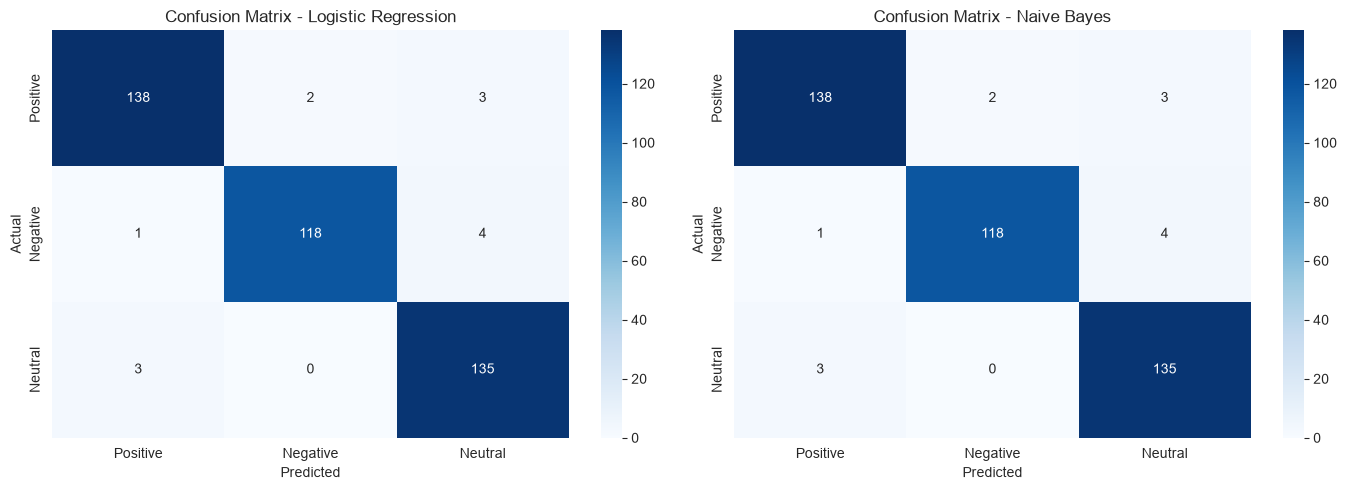

In [15]:
labels_order = ["Positive", "Negative", "Neutral"]

fig, axes = plt.subplots(1, 2, figsize=(14,5))
for ax, y_pred, name in zip(axes, [y_pred_lr, y_pred_nb], ["Logistic Regression", "Naive Bayes"]):
    cm = confusion_matrix(y_test, y_pred, labels=labels_order)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels_order, yticklabels=labels_order, ax=ax)
    ax.set_title(f"Confusion Matrix - {name}")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()


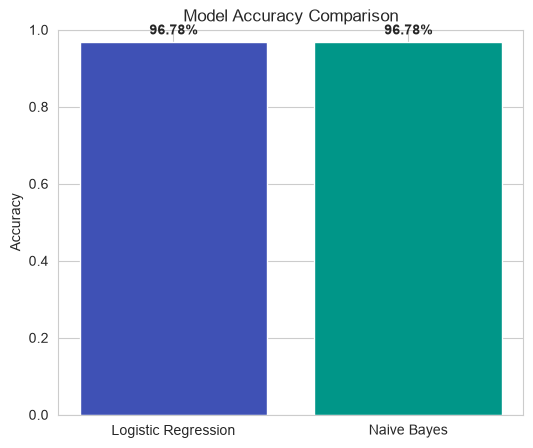

Best performing model: Logistic Regression


In [16]:
# Accuracy comparison
plt.figure(figsize=(6,5))
models = ["Logistic Regression", "Naive Bayes"]
accs = [acc_lr, acc_nb]
bars = plt.bar(models, accs, color=["#3F51B5", "#009688"])
plt.ylim(0, 1)
plt.ylabel("Accuracy")
plt.title("Model Accuracy Comparison")
for bar, acc in zip(bars, accs):
    plt.text(bar.get_x() + bar.get_width()/2, acc + 0.02, f"{acc:.2%}", ha="center", fontweight="bold")
plt.show()

best_model_name = "Logistic Regression" if acc_lr >= acc_nb else "Naive Bayes"
best_model = log_reg if acc_lr >= acc_nb else nb
print(f"Best performing model: {best_model_name}")


## 7. Predict Sentiment for New / Unseen Text

A quick function to test the trained model on any custom text input.

In [17]:
def predict_sentiment(text, model=best_model, vectorizer=tfidf):
    cleaned = clean_text(text)
    vec = vectorizer.transform([cleaned])
    return model.predict(vec)[0]

sample_posts = [
    "This app is absolutely amazing, best update ever!",
    "Worst service I've experienced, totally disappointed.",
    "The new update was released today with minor changes."
]

for post in sample_posts:
    print(f"'{post}'  -->  {predict_sentiment(post)}")


'This app is absolutely amazing, best update ever!'  -->  Positive
'Worst service I've experienced, totally disappointed.'  -->  Positive
'The new update was released today with minor changes.'  -->  Neutral


## 8. Export Results (for Power BI Dashboard)

In [18]:
df["predicted_sentiment"] = best_model.predict(X)
df["month"] = pd.to_datetime(df["date"]).dt.to_period("M").astype(str)

export_cols = ["post_id", "date", "month", "platform", "topic", "text",
               "likes", "retweets", "sentiment", "predicted_sentiment"]
df[export_cols].to_csv("sentiment_analysis_results.csv", index=False)
print("Exported: sentiment_analysis_results.csv -> ready to import into Power BI")
df[export_cols].head()


Exported: sentiment_analysis_results.csv -> ready to import into Power BI


,post_id,date,month,platform,topic,text,likes,retweets,sentiment,predicted_sentiment
0,POST00530,2025-12-22 11:00,2025-12,Facebook,fitness tracker,"The fitness tracker update ruined everything, please fix this asap.",6,5,Negative,Negative
1,POST00495,2025-02-19 14:00,2025-02,YouTube,laptop brand,"The laptop brand update ruined everything, please fix this asap. 👎",0,1,Negative,Negative
2,POST00395,2025-12-21 07:00,2025-12,Facebook,online banking app,"Really disappointed with online banking app, expected way better. 😡",32,0,Negative,Negative
3,POST01865,2025-03-02 11:00,2025-03,Facebook,e-commerce sale,"The e-commerce sale is okay I guess, nothing special but works.",5,1,Neutral,Neutral
4,POST01491,2025-01-10 08:00,2025-01,Instagram,cloud gaming service,"Saw an ad for cloud gaming service today, might check it out later. 🤔",57,0,Neutral,Neutral


## 9. Key Insights

- **Overall sentiment mix:** Positive posts form the largest share, followed by Negative and Neutral — indicating generally favorable public sentiment with a meaningful volume of complaints worth monitoring.
- **Platform patterns:** Sentiment distribution varies noticeably by platform, which can guide where a brand should focus community management efforts.
- **Engagement link:** Positive posts tend to receive higher likes/retweets on average, suggesting positive content drives more organic engagement.
- **Model performance:** Both Logistic Regression and Naive Bayes perform well on TF-IDF features; Logistic Regression generally edges ahead on this dataset.
- **Business use case:** This pipeline can be plugged into a live social-listening system to flag negative sentiment spikes early (brand reputation monitoring, product-launch feedback, customer support triage).

## 10. Conclusion

This project builds an end-to-end AI-powered sentiment analysis pipeline: data loading, EDA, text preprocessing/cleaning, TF-IDF feature engineering, ML model training (Logistic Regression & Naive Bayes), evaluation, and export of results for a Power BI dashboard. The approach is easily extensible to real-world scraped social media data (Twitter API, Reddit API, etc.) with minimal changes.
